# Analysis of Zelda Dungeon Data from VGLC

## Setup

In [19]:
import pandas as pd

zelda_df = pd.read_csv('zelda_data.csv')
zelda_df

,game,level,number_nodes,number_edges,number_true_edges,number_normal_keys,number_boss_keys,number_key_items,number_switches,number_normal_locks,number_boss_locks,number_key_item_locks,number_switch_locks,avg_out_rank,avg_true_out_rank
0,The Legend of Zelda,LoZ_5,25,54,52,3,0,1,0,12,0,0,0,2.160000,2.080000
1,The Legend of Zelda,LoZ_7,35,76,76,4,0,1,0,10,0,0,0,2.171429,2.171429
2,The Legend of Zelda,LoZ2_6,30,66,66,3,0,1,0,6,0,20,0,2.200000,2.200000
3,The Legend of Zelda,LoZ_9,62,144,140,4,0,2,0,32,0,0,0,2.322581,2.258065
4,The Legend of Zelda,LoZ2_4,35,83,83,4,0,2,0,6,0,2,0,2.371429,2.371429
5,The Legend of Zelda,LoZ2_7,31,61,61,2,0,1,0,4,0,0,0,1.967742,1.967742
6,The Legend of Zelda,LoZ2_9,66,161,151,0,0,2,1,0,0,0,2,2.439394,2.287879
7,The Legend of Zelda,LoZ_4,27,60,58,4,0,1,0,12,0,8,0,2.222222,2.148148
8,The Legend of Zelda,LoZ_6,27,58,58,4,0,1,0,10,0,0,0,2.148148,2.148148
9,The Legend of Zelda,LoZ2_2,23,51,49,8,0,1,0,8,0,0,0,2.217391,2.130435


In [20]:
zelda_df['number_all_keys'] = zelda_df['number_normal_keys'] + zelda_df['number_boss_keys'] + zelda_df['number_key_items'] + zelda_df['number_switches']
zelda_df['number_all_locks'] = zelda_df['number_normal_locks'] + zelda_df['number_boss_locks'] + zelda_df['number_key_item_locks'] + zelda_df['number_switch_locks']
zelda_df

,game,level,number_nodes,number_edges,number_true_edges,number_normal_keys,number_boss_keys,number_key_items,number_switches,number_normal_locks,number_boss_locks,number_key_item_locks,number_switch_locks,avg_out_rank,avg_true_out_rank,number_all_keys,number_all_locks
0,The Legend of Zelda,LoZ_5,25,54,52,3,0,1,0,12,0,0,0,2.160000,2.080000,4,12
1,The Legend of Zelda,LoZ_7,35,76,76,4,0,1,0,10,0,0,0,2.171429,2.171429,5,10
2,The Legend of Zelda,LoZ2_6,30,66,66,3,0,1,0,6,0,20,0,2.200000,2.200000,4,26
3,The Legend of Zelda,LoZ_9,62,144,140,4,0,2,0,32,0,0,0,2.322581,2.258065,6,32
4,The Legend of Zelda,LoZ2_4,35,83,83,4,0,2,0,6,0,2,0,2.371429,2.371429,6,8
5,The Legend of Zelda,LoZ2_7,31,61,61,2,0,1,0,4,0,0,0,1.967742,1.967742,3,4
6,The Legend of Zelda,LoZ2_9,66,161,151,0,0,2,1,0,0,0,2,2.439394,2.287879,3,2
7,The Legend of Zelda,LoZ_4,27,60,58,4,0,1,0,12,0,8,0,2.222222,2.148148,5,20
8,The Legend of Zelda,LoZ_6,27,58,58,4,0,1,0,10,0,0,0,2.148148,2.148148,5,10
9,The Legend of Zelda,LoZ2_2,23,51,49,8,0,1,0,8,0,0,0,2.217391,2.130435,9,8


## Analysis

### Number of Nodes

In [21]:
zelda_df['number_nodes'].describe()

count    38.000000
mean     33.684211
std      14.155708
min      12.000000
25%      23.500000
50%      31.000000
75%      39.750000
max      66.000000
Name: number_nodes, dtype: float64

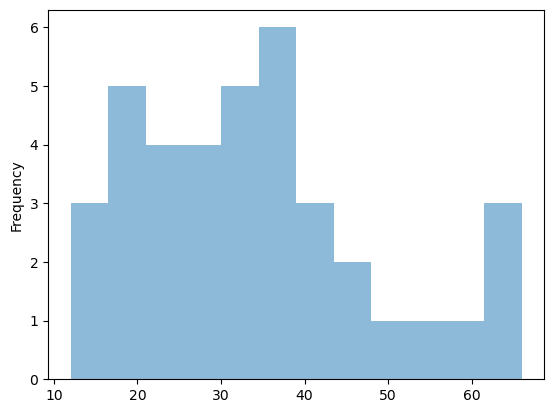

In [22]:
ax = zelda_df['number_nodes'].plot.hist(bins=12, alpha=0.5)

### Number of Edges

In [23]:
zelda_df['number_edges'].describe()

count     38.000000
mean      74.763158
std       33.603760
min       22.000000
25%       51.750000
50%       66.000000
75%       94.000000
max      161.000000
Name: number_edges, dtype: float64

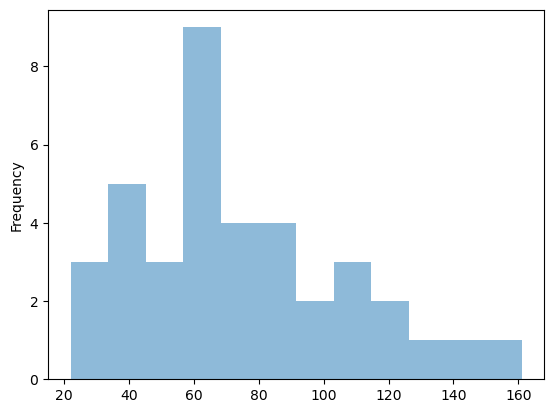

In [24]:
ax = zelda_df['number_edges'].plot.hist(bins=12, alpha=0.5)

### Average Rank per Node

In [25]:
zelda_df['avg_out_rank'].describe()

count    38.000000
mean      2.196186
std       0.204523
min       1.833333
25%       2.053571
50%       2.166795
75%       2.318947
max       2.750000
Name: avg_out_rank, dtype: float64

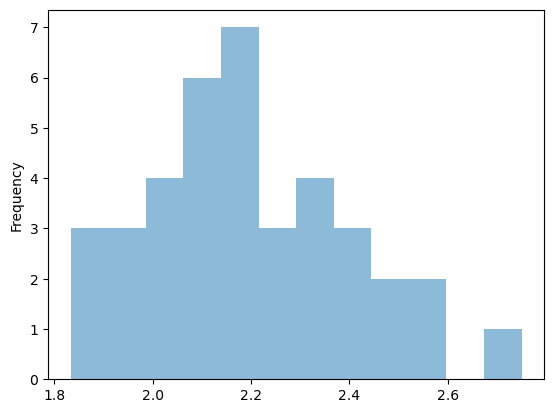

In [26]:
ax = zelda_df['avg_out_rank'].plot.hist(bins=12, alpha=0.5)

### Number of Keys (Total)

In [27]:
zelda_df['number_all_keys'].describe()

count    38.000000
mean      6.815789
std       2.865029
min       3.000000
25%       5.000000
50%       6.000000
75%       8.750000
max      13.000000
Name: number_all_keys, dtype: float64

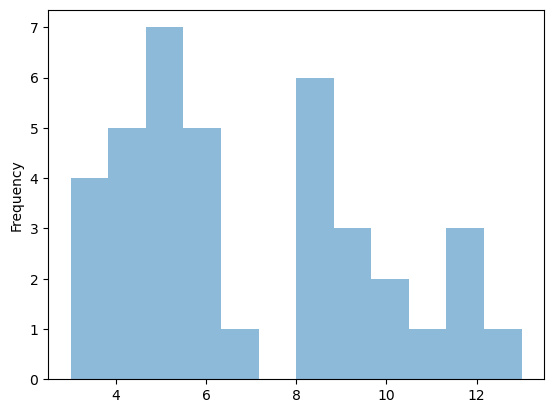

In [28]:
ax = zelda_df['number_all_keys'].plot.hist(bins=12, alpha=0.5)

### Number of Locks (Total)

In [29]:
zelda_df['number_all_locks'].describe()

count    38.000000
mean     14.473684
std       8.484443
min       2.000000
25%       8.000000
50%      12.000000
75%      21.500000
max      32.000000
Name: number_all_locks, dtype: float64

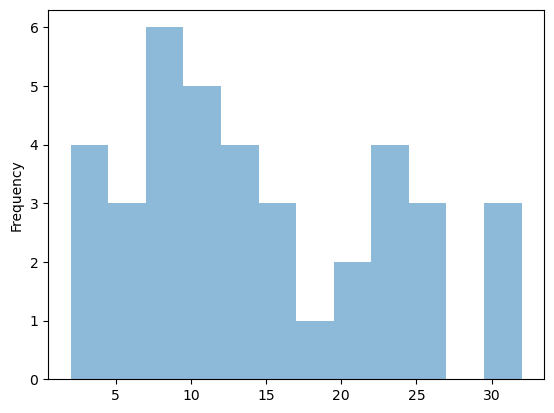

In [30]:
ax = zelda_df['number_all_locks'].plot.hist(bins=12, alpha=0.5)

### Number of Keys (By Type)

In [31]:
zelda_keys_df = zelda_df[[
    'number_normal_keys',
    'number_boss_keys',
    'number_key_items',
    'number_switches'
]]

In [32]:
zelda_keys_df.describe()

,number_normal_keys,number_boss_keys,number_key_items,number_switches
count,38.000000,38.000000,38.000000,38.000000
mean,4.236842,0.500000,1.131579,0.947368
std,2.032629,0.506712,0.414015,2.091778
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,1.000000,0.000000
50%,4.000000,0.500000,1.000000,0.000000
75%,6.000000,1.000000,1.000000,1.000000
max,8.000000,1.000000,2.000000,11.000000


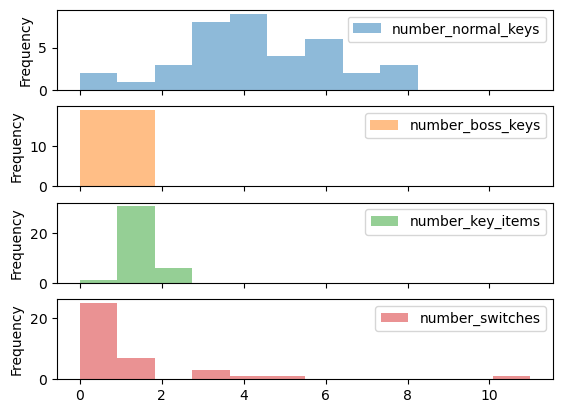

In [33]:
ax = zelda_keys_df.plot.hist(bins=12, alpha=0.5, subplots=True)

### Number of Locks (By Type)

In [34]:
zelda_locks_df = zelda_df[[
    'number_normal_locks',
    'number_boss_locks',
    'number_key_item_locks',
    'number_switch_locks'
]]

In [35]:
zelda_locks_df.describe()

,number_normal_locks,number_boss_locks,number_key_item_locks,number_switch_locks
count,38.000000,38.000000,38.000000,38.000000
mean,8.894737,1.000000,2.789474,1.789474
std,5.578867,1.294479,4.960154,4.179473
min,0.000000,0.000000,0.000000,0.000000
25%,6.000000,0.000000,0.000000,0.000000
50%,8.000000,0.000000,0.000000,0.000000
75%,12.000000,2.000000,4.000000,2.000000
max,32.000000,4.000000,20.000000,22.000000


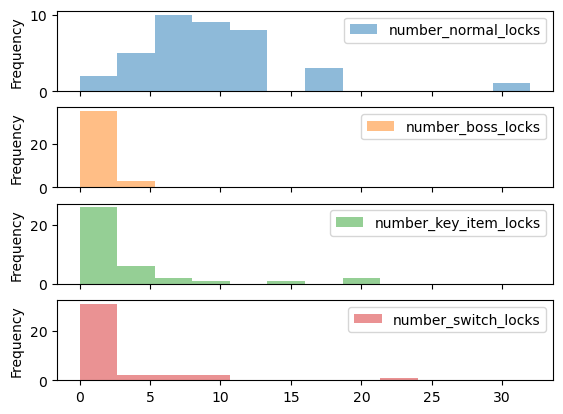

In [36]:
ax = zelda_locks_df.plot.hist(bins=12, alpha=0.5, subplots=True)